## 📦 Section 1 — Install Dependencies

In [1]:
# Only run this cell if you haven't installed requirements yet
# !pip install tensorflow==2.15.0 opencv-python-headless requests scikit-learn matplotlib pandas pillow flask flask-cors

## ⚙️ Section 2 — Imports & Global Configuration

In [2]:
from pathlib import Path
import os, random, shutil, zipfile, urllib.request, json, warnings
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support,
)
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Reproducibility seeds ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU memory growth (safe for multi-GPU setups) ─────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print('✅ TensorFlow :', tf.__version__)
print('✅ OpenCV     :', cv2.__version__)
print('✅ NumPy      :', np.__version__)
print('✅ GPU devices:', gpus if gpus else 'None (CPU mode)')

✅ TensorFlow : 2.19.1
✅ OpenCV     : 4.13.0
✅ NumPy      : 2.1.3
✅ GPU devices: None (CPU mode)


## 📁 Section 3 — Project Directory Structure

In [3]:
# ── Project root — change this path if needed ────────────────────────────────
PROJECT_DIR   = Path('./agrointelli_data')
DATA_DIR      = PROJECT_DIR / 'data'
RAW_DIR       = DATA_DIR / 'raw'
INTERIM_DIR   = DATA_DIR / 'interim'
PROCESSED_DIR = DATA_DIR / 'processed'
TRAIN_DIR     = PROCESSED_DIR / 'train'
VAL_DIR       = PROCESSED_DIR / 'val'
TEST_DIR      = PROCESSED_DIR / 'test'
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'
MODEL_DIR     = ARTIFACTS_DIR / 'models'
PLOT_DIR      = ARTIFACTS_DIR / 'plots'
REPORT_DIR    = ARTIFACTS_DIR / 'reports'
GRADCAM_DIR   = ARTIFACTS_DIR / 'gradcam'

for d in [RAW_DIR, INTERIM_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
          MODEL_DIR, PLOT_DIR, REPORT_DIR, GRADCAM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Directory structure ready.')
print(f'   Root: {PROJECT_DIR.resolve()}')

✅ Directory structure ready.
   Root: C:\Users\rahul\Desktop\pd\AgroIntelli_Project\notebooks\agrointelli_data


## ⬇️ Section 4 — Dataset Download

| Dataset | Source | Characteristics |
|---|---|---|
| **PlantVillage** | Mendeley Data | ~54,000 lab-quality images, consistent backgrounds |
| **PlantDoc** | GitHub (Pratik Kayal) | ~2,500 field images, real-world noise & backgrounds |

> ⏱️ Downloads may take 5–15 minutes depending on connection speed. Files are cached — re-running is safe.

In [5]:
def download_file(url, dst):
    """Download a file with progress display. Skips if already downloaded."""
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        print(f'  ✓ Already downloaded: {dst.name}')
        return
    print(f'  ⬇ Downloading {dst.name} ...')
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as resp, open(dst, 'wb') as out:
        total = int(resp.headers.get('Content-Length', 0))
        downloaded = 0
        chunk = 1 << 20  # 1 MB chunks
        while True:
            block = resp.read(chunk)
            if not block:
                break
            out.write(block)
            downloaded += len(block)
            if total:
                pct = downloaded * 100 // total
                print(f'\r    {pct:3d}%  ({downloaded >> 20}/{total >> 20} MB)', end='')
    print('\n  ✓ Download complete.')


def unzip_file(zip_path, extract_to):
    """Extract a ZIP archive. Skips if already extracted."""
    extract_to.mkdir(parents=True, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            names = zf.namelist()
            first_entry = extract_to / names[0]
            if first_entry.exists():
                print(f'  ✓ Already extracted: {extract_to.name}')
                return
            print(f'  📦 Extracting {zip_path.name} ...')
            zf.extractall(extract_to)
        print('  ✓ Extraction complete.')
    except zipfile.BadZipFile as e:
        print(f'  ✗ Bad ZIP file ({e}). Re-download required.')
        zip_path.unlink(missing_ok=True)
        raise


# ── PlantVillage ──────────────────────────────────────────────────────────────
PV_URL = ('https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/'
          'b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded')
PV_ZIP = RAW_DIR / 'plantvillage.zip'
PV_DIR = RAW_DIR / 'plantvillage'

print('PlantVillage:')
download_file(PV_URL, PV_ZIP)
unzip_file(PV_ZIP, PV_DIR)

# ── PlantDoc ──────────────────────────────────────────────────────────────────
PD_URL = 'https://github.com/pratikkayal/PlantDoc-Dataset/archive/refs/heads/master.zip'
PD_ZIP = RAW_DIR / 'plantdoc.zip'
PD_DIR = RAW_DIR / 'plantdoc'

print('\nPlantDoc:')
download_file(PD_URL, PD_ZIP)
unzip_file(PD_ZIP, PD_DIR)

PlantVillage:
  ⬇ Downloading plantvillage.zip ...
    100%  (905/905 MB)
  ✓ Download complete.
  📦 Extracting plantvillage.zip ...
  ✓ Extraction complete.

PlantDoc:
  ⬇ Downloading plantdoc.zip ...

  ✓ Download complete.
  📦 Extracting plantdoc.zip ...
  ✓ Extraction complete.


## 🔍 Section 5 — Dataset Discovery & Label Standardization

PlantVillage uses `Tomato___Early_blight`; PlantDoc uses `Tomato Early blight`.  
We normalise all names to a canonical `{crop}_{condition}` schema.

### Supported Classes (10 total)

| Class Label | Description |
|---|---|
| `tomato_early_blight` | Alternaria solani infection |
| `tomato_late_blight` | Phytophthora infestans infection |
| `tomato_healthy` | Healthy tomato leaf |
| `potato_early_blight` | Early-stage fungal blight |
| `potato_late_blight` | Late-stage water mould infection |
| `potato_healthy` | Healthy potato leaf |
| `pepper_bacterial_spot` | Xanthomonas bacterial infection |
| `pepper_healthy` | Healthy pepper leaf |
| `corn_common_rust` | Puccinia sorghi fungal rust |
| `corn_healthy` | Healthy corn/maize leaf |

In [6]:
TARGET_CROPS = ['Tomato', 'Potato', 'Pepper', 'Corn']
IMG_EXTS     = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

LABEL_MAP = {
    'Tomato___Early_blight'        : 'tomato_early_blight',
    'Tomato___Late_blight'         : 'tomato_late_blight',
    'Tomato___healthy'             : 'tomato_healthy',
    'Tomato Early blight'          : 'tomato_early_blight',
    'Tomato Late blight'           : 'tomato_late_blight',
    'Tomato leaf'                  : 'tomato_healthy',
    'Potato___Early_blight'        : 'potato_early_blight',
    'Potato___Late_blight'         : 'potato_late_blight',
    'Potato___healthy'             : 'potato_healthy',
    'Potato Early blight'          : 'potato_early_blight',
    'Potato Late blight'           : 'potato_late_blight',
    'Pepper__bell___Bacterial_spot': 'pepper_bacterial_spot',
    'Pepper__bell___healthy'       : 'pepper_healthy',
    'Pepper__bell__Bacterial_spot' : 'pepper_bacterial_spot',
    'Corn_(maize)___Common_rust_'  : 'corn_common_rust',
    'Corn_(maize)___healthy'       : 'corn_healthy',
    'Corn Common rust'             : 'corn_common_rust',
    'Corn leaf blight'             : 'corn_common_rust',
}


def normalize_label(folder_name):
    """Map a raw folder name to a canonical label. Returns None if unrecognised."""
    for key, label in LABEL_MAP.items():
        if key.lower().replace(' ', '_') in folder_name.lower().replace(' ', '_'):
            return label
    return None


def discover_images(root_dir):
    """Recursively find all images for target crops under root_dir."""
    root_dir = Path(root_dir)
    if not root_dir.exists():
        print(f'  ⚠ Directory not found: {root_dir} — returning empty DataFrame.')
        return pd.DataFrame(columns=['path', 'class_name'])
    rows = []
    for path in root_dir.rglob('*'):
        if path.suffix.lower() in IMG_EXTS:
            class_name = path.parent.name
            if any(crop.lower() in class_name.lower() for crop in TARGET_CROPS):
                rows.append({'path': str(path), 'class_name': class_name})
    return pd.DataFrame(rows) if rows else pd.DataFrame(columns=['path', 'class_name'])


pv_df = discover_images(PV_DIR)
pd_df = discover_images(PD_DIR)

if not pv_df.empty:
    pv_df['label'] = pv_df['class_name'].apply(normalize_label)
if not pd_df.empty:
    pd_df['label'] = pd_df['class_name'].apply(normalize_label)

pv_df['source'] = 'plantvillage'
pd_df['source'] = 'plantdoc'

pv_df = pv_df[pv_df['label'].notna()].copy() if 'label' in pv_df.columns else pv_df
pd_df = pd_df[pd_df['label'].notna()].copy() if 'label' in pd_df.columns else pd_df

print(f'PlantVillage — {len(pv_df):,} images across {pv_df["label"].nunique() if "label" in pv_df.columns else 0} classes')
print(f'PlantDoc     — {len(pd_df):,} images across {pd_df["label"].nunique() if "label" in pd_df.columns else 0} classes')
print()
print('PlantVillage class distribution:')
display(pv_df['label'].value_counts().rename('count').to_frame() if 'label' in pv_df.columns else pd.DataFrame())
print('\nPlantDoc class distribution:')
display(pd_df['label'].value_counts().rename('count').to_frame() if 'label' in pd_df.columns else pd.DataFrame())

PlantVillage — 7,500 images across 6 classes
PlantDoc     — 693 images across 3 classes

PlantVillage class distribution:


,count
label,
tomato_late_blight,1909
tomato_healthy,1591
potato_healthy,1000
potato_early_blight,1000
tomato_early_blight,1000
potato_late_blight,1000



PlantDoc class distribution:


,count
label,
tomato_healthy,414
corn_common_rust,191
tomato_early_blight,88


## 🔀 Section 6 — Dataset Merge, Split & Class Distribution

| Split | Proportion | Purpose |
|---|---|---|
| Train | 80% | Model weight updates |
| Validation | 10% | Hyperparameter tuning, early stopping |
| Test | 10% | Final unbiased evaluation |

Total merged dataset: 8,193 images, 7 classes

Split sizes → Train: 6,554  |  Val: 819  |  Test: 820


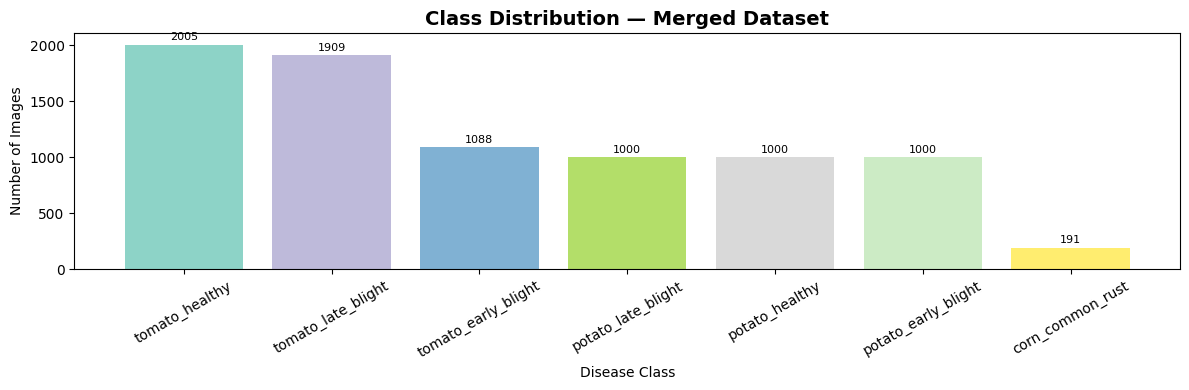

In [7]:
merged_df = pd.concat([pv_df, pd_df], ignore_index=True)
print(f'Total merged dataset: {len(merged_df):,} images, {merged_df["label"].nunique()} classes')

if merged_df.empty or merged_df['label'].nunique() < 2:
    raise RuntimeError(
        'Merged dataset is empty or has fewer than 2 classes. '
        'Ensure datasets downloaded and extracted correctly (run Section 4 first).'
    )

# Drop classes with fewer than 2 samples (stratified split requires at least 2)
class_counts = merged_df['label'].value_counts()
singleton_classes = class_counts[class_counts < 2].index.tolist()
if singleton_classes:
    print(f'⚠ Dropping {len(singleton_classes)} class(es) with < 2 samples: {singleton_classes}')
    merged_df = merged_df[~merged_df['label'].isin(singleton_classes)].copy()

# ── Stratified 80/10/10 split ─────────────────────────────────────────────────
train_df, temp_df = train_test_split(
    merged_df, test_size=0.20, random_state=SEED, stratify=merged_df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f'\nSplit sizes → Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')

# ── Class distribution chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
counts = merged_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=plt.cm.Set3(np.linspace(0, 1, len(counts))))
ax.set_title('Class Distribution — Merged Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease Class')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'class_distribution.png', dpi=150)
plt.show()

## ⚙️ Section 7 — TensorFlow Data Pipeline & Augmentation

### Dual-Input Design
Each sample has two inputs:
1. Leaf image `(224, 224, 3)` — raw `[0, 255]` float32 (EfficientNetB0 preprocesses internally)
2. Weather feature vector `(4,)` — zeros for archive images, real values for live field images

### Augmentations Applied During Training
| Augmentation | Simulates |
|---|---|
| Random horizontal flip | Left/right leaf orientation |
| Random rotation ±10° | Camera tilt in field photos |
| Random zoom ±10% | Varying photo distance |
| Random translation ±10% | Leaf not centred in frame |

In [8]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE
WEATHER_DIM = 4

# ── Class index mapping ───────────────────────────────────────────────────────
class_names  = sorted(merged_df['label'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES  = len(class_names)

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df['target'] = train_df['label'].map(class_to_idx)
val_df['target']   = val_df['label'].map(class_to_idx)
test_df['target']  = test_df['label'].map(class_to_idx)

print(f'Number of classes : {NUM_CLASSES}')
for k, v in class_to_idx.items():
    print(f'  [{v:2d}] {k}')


def preprocess_image(path, label):
    """
    Decode, resize, and cast to float32 in [0, 255].
    EfficientNetB0 has a built-in preprocessing layer that expects [0, 255] input.
    DO NOT divide by 255 here — that would corrupt EfficientNet's internal rescaling.
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)  # keep [0, 255]
    weather_zeros = tf.zeros([WEATHER_DIM], dtype=tf.float32)
    return (img, weather_zeros), label


def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['target'].values.astype(np.int32))
    )
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=5000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print('\n✅ tf.data pipelines ready.')
print('   Images kept as [0, 255] float32 — EfficientNetB0 preprocesses internally.')
print(f'   Batches per epoch (train): {len(train_ds)}')

Number of classes : 7
  [ 0] corn_common_rust
  [ 1] potato_early_blight
  [ 2] potato_healthy
  [ 3] potato_late_blight
  [ 4] tomato_early_blight
  [ 5] tomato_healthy
  [ 6] tomato_late_blight

✅ tf.data pipelines ready.
   Images kept as [0, 255] float32 — EfficientNetB0 preprocesses internally.
   Batches per epoch (train): 205


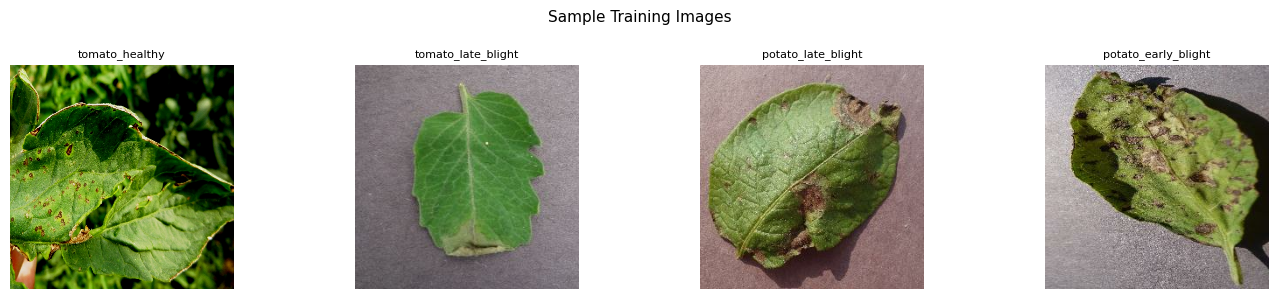

In [9]:
# ── Augmentation layers ───────────────────────────────────────────────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name='data_augmentation')

# ── Sanity check: visualise sample images ─────────────────────────────────────
(sample_images, sample_weather), sample_labels = next(iter(train_ds))

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i in range(4):
    axes[i].imshow(np.clip(sample_images[i].numpy() / 255.0, 0, 1))
    axes[i].set_title(class_names[sample_labels[i].numpy()], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Sample Training Images', fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sample_images.png', dpi=150)
plt.show()

## 🧠 Section 8 — EfficientNetB0 Model Architecture

### Why EfficientNetB0?
| Property | MobileNetV3 | EfficientNetB0 |
|---|---|---|
| Parameters | ~5.4M | ~5.3M |
| ImageNet top-1 | ~75% | ~77.1% |
| Field robustness | Lower | Higher |
| CPU inference | Fast | Fast |

### Weather-Aware Architecture
- **Image branch**: EfficientNetB0 backbone → GAP → Dense(256) → BN → Dropout(0.3)
- **Weather branch**: Dense(32) → Dense(16)
- **Fusion**: Concatenate → Dense(128) → Softmax(10 classes)

For archive images, the weather branch receives zeros and is effectively silent.

In [10]:
STAGE1_EPOCHS = 20
STAGE1_LR     = 1e-3
STAGE2_LR     = 1e-4


def build_model(num_classes, img_size=IMG_SIZE, weather_dim=WEATHER_DIM):
    """
    EfficientNetB0 transfer learning model with weather-aware fusion.
    Images must be fed as [0, 255] float32 — backbone handles rescaling internally.
    """
    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3),
    )
    backbone.trainable = False

    # ── Image branch ──────────────────────────────────────────────────────────
    image_input = keras.Input(shape=(img_size, img_size, 3), name='input_image')
    x = data_augmentation(image_input)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, activation='relu', name='fc256')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(0.3, name='dropout_head')(x)

    # ── Weather branch ────────────────────────────────────────────────────────
    weather_input = keras.Input(shape=(weather_dim,), name='weather_input')
    w = layers.Dense(32, activation='relu', name='weather_fc1')(weather_input)
    w = layers.Dense(16, activation='relu', name='weather_fc2')(w)

    # ── Fusion ────────────────────────────────────────────────────────────────
    fused   = layers.Concatenate(name='fuse')([x, w])
    fused   = layers.Dense(128, activation='relu', name='fuse_fc')(fused)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(fused)

    return keras.Model(
        inputs=[image_input, weather_input],
        outputs=outputs,
        name='AgroIntelli_WeatherAware'
    ), backbone


model, backbone = build_model(NUM_CLASSES)


def smooth_sparse_crossentropy(y_true, y_pred, smoothing=0.1):
    """Sparse categorical crossentropy with label smoothing."""
    y_onehot = tf.one_hot(tf.cast(y_true, tf.int32), NUM_CLASSES)
    y_smooth = y_onehot * (1.0 - smoothing) + (smoothing / NUM_CLASSES)
    return tf.reduce_mean(
        -tf.reduce_sum(y_smooth * tf.math.log(tf.clip_by_value(y_pred, 1e-7, 1.0)), axis=-1)
    )


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss=smooth_sparse_crossentropy,
    metrics=['accuracy']
)

model.summary()
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f'\nTrainable params : {trainable:,}')
print('✅ Model built. Images fed as [0, 255] — EfficientNetB0 preprocesses internally.')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "AgroIntelli_WeatherAware"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape      ┃    Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_image          │ (None, 224, 224,  │          0 │ -                  │
│ (InputLayer)         │ 3)                │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ data_augmentation    │ (None, 224, 224,  │          0 │ input_image[0][0]  │
│ (Sequential)         │ 3)                │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ efficientnetb0       │ (None, 7, 7,      │  4,049,571 │ data_augmentation… │
│ (Functional)         │ 1280)             │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ gap                  │ (None, 1280)      │          0 │ efficientnetb0[0]… │
│ (GlobalAveragePooli… │                   │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ fc256 (Dense)        │ (None, 256)       │    327,936 │ gap[0][0]          │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ weather_input        │ (None, 4)         │          0 │ -                  │
│ (InputLayer)         │                   │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ bn_head              │ (None, 256)       │      1,024 │ fc256[0][0]        │
│ (BatchNormalization) │                   │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ weather_fc1 (Dense)  │ (None, 32)        │        160 │ weather_input[0][… │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ dropout_head         │ (None, 256)       │          0 │ bn_head[0][0]      │
│ (Dropout)            │                   │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ weather_fc2 (Dense)  │ (None, 16)        │        528 │ weather_fc1[0][0]  │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ fuse (Concatenate)   │ (None, 272)       │          0 │ dropout_head[0][0… │
│                      │                   │            │ weather_fc2[0][0]  │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ fuse_fc (Dense)      │ (None, 128)       │     34,944 │ fuse[0][0]         │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ predictions (Dense)  │ (None, 7)         │        903 │ fuse_fc[0][0]      │
└──────────────────────┴───────────────────┴────────────┴────────────────────┘

 Total params: 4,415,066 (16.84 MB)

 Trainable params: 364,983 (1.39 MB)

 Non-trainable params: 4,050,083 (15.45 MB)


Trainable params : 364,983
✅ Model built. Images fed as [0, 255] — EfficientNetB0 preprocesses internally.


## ⚖️ Section 9 — Class Weights & Training Callbacks

| Callback | Purpose |
|---|---|
| `ModelCheckpoint` | Saves best model by validation accuracy |
| `EarlyStopping` | Stops when val_acc plateaus |
| `ReduceLROnPlateau` | Drops LR × 0.3 if val_loss stalls |

In [11]:
# ── Class weights (corrects for PlantDoc/PlantVillage imbalance) ──────────────
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['target']),
    y=train_df['target'].values
)
class_weights = dict(enumerate(weights_array))
print('Class weights:')
for idx, w in class_weights.items():
    print(f'  [{idx:2d}] {class_names[idx]:<30s} → {w:.3f}')

STAGE1_MODEL_PATH = str(MODEL_DIR / 'best_model_stage1.keras')
STAGE2_MODEL_PATH = str(MODEL_DIR / 'best_model_stage2.keras')

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE1_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3,
        min_lr=1e-6, verbose=1
    ),
]

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE2_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=2,
        min_lr=1e-7, verbose=1
    ),
]

print('\n✅ Callbacks configured.')

Class weights:
  [ 0] corn_common_rust               → 6.120
  [ 1] potato_early_blight            → 1.170
  [ 2] potato_healthy                 → 1.170
  [ 3] potato_late_blight             → 1.170
  [ 4] tomato_early_blight            → 1.076
  [ 5] tomato_healthy                 → 0.584
  [ 6] tomato_late_blight             → 0.613

✅ Callbacks configured.


## 🏋️ Section 10 — Model Training

### Stage 1: Feature Extraction (backbone frozen)
Only the classification head trains. Fast on CPU, establishes a strong starting point.

### Stage 2: Fine-Tuning (top 50 backbone layers unfrozen)
Very low LR (1e-4) allows the backbone to adapt to agricultural leaf textures.

> ⏱️ **Expected CPU training time:** Stage 1 ≈ 30–60 min | Stage 2 ≈ 15–30 min

In [12]:
print('=' * 60)
print('STAGE 1 — Feature Extraction (backbone frozen)')
print(f'  LR: {STAGE1_LR}  |  ReduceLROnPlateau (patience=3, factor=0.3)')
print(f'  Epochs: up to {STAGE1_EPOCHS} with EarlyStopping (patience=7)')
print('=' * 60)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    class_weight=class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)

STAGE 1 — Feature Extraction (backbone frozen)
  LR: 0.001  |  ReduceLROnPlateau (patience=3, factor=0.3)
  Epochs: up to 20 with EarlyStopping (patience=7)
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.7850 - loss: 0.9621
Epoch 1: val_accuracy improved from None to 0.94383, saving model to agrointelli_data\artifacts\models\best_model_stage1.keras

Epoch 1: finished saving model to agrointelli_data\artifacts\models\best_model_stage1.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 184s 807ms/step - accuracy: 0.8612 - loss: 0.8081 - val_accuracy: 0.9438 - val_loss: 0.6446 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.9245 - loss: 0.6573
Epoch 2: val_accuracy did not improve from 0.94383
205/205 ━━━━━━━━━━━━━━━━━━━━ 162s 771ms/step - accuracy: 0.9262 - loss: 0.6626 - val_accuracy: 0.9426 - val_loss: 0.6336 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.9452 - loss: 0.6389
Epoch 3: val_accur

In [13]:
print('=' * 60)
print('STAGE 2 — Fine-tuning (top 50 backbone layers unfrozen)')
print(f'  LR: {STAGE2_LR}  |  ReduceLROnPlateau')
print('=' * 60)

backbone.trainable = True
for layer in backbone.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in backbone.layers if l.trainable)
print(f'  Backbone trainable layers: {trainable_count} / {len(backbone.layers)}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss=smooth_sparse_crossentropy,
    metrics=['accuracy']
)

STAGE2_EPOCHS = len(history1.history['accuracy']) + 20

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=len(history1.history['accuracy']),
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks,
    verbose=1
)

STAGE 2 — Fine-tuning (top 50 backbone layers unfrozen)
  LR: 0.0001  |  ReduceLROnPlateau
  Backbone trainable layers: 50 / 238
Epoch 21/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.9182 - loss: 0.6662
Epoch 21: val_accuracy improved from None to 0.97802, saving model to agrointelli_data\artifacts\models\best_model_stage2.keras

Epoch 21: finished saving model to agrointelli_data\artifacts\models\best_model_stage2.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.9457 - loss: 0.6060 - val_accuracy: 0.9780 - val_loss: 0.5154 - learning_rate: 1.0000e-04
Epoch 22/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.9757 - loss: 0.5404
Epoch 22: val_accuracy improved from 0.97802 to 0.98168, saving model to agrointelli_data\artifacts\models\best_model_stage2.keras

Epoch 22: finished saving model to agrointelli_data\artifacts\models\best_model_stage2.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 201s 960ms/step - accuracy: 0.9767 - loss: 0.5333 - val_accuracy: 0.981

## 📊 Section 11 — Model Evaluation

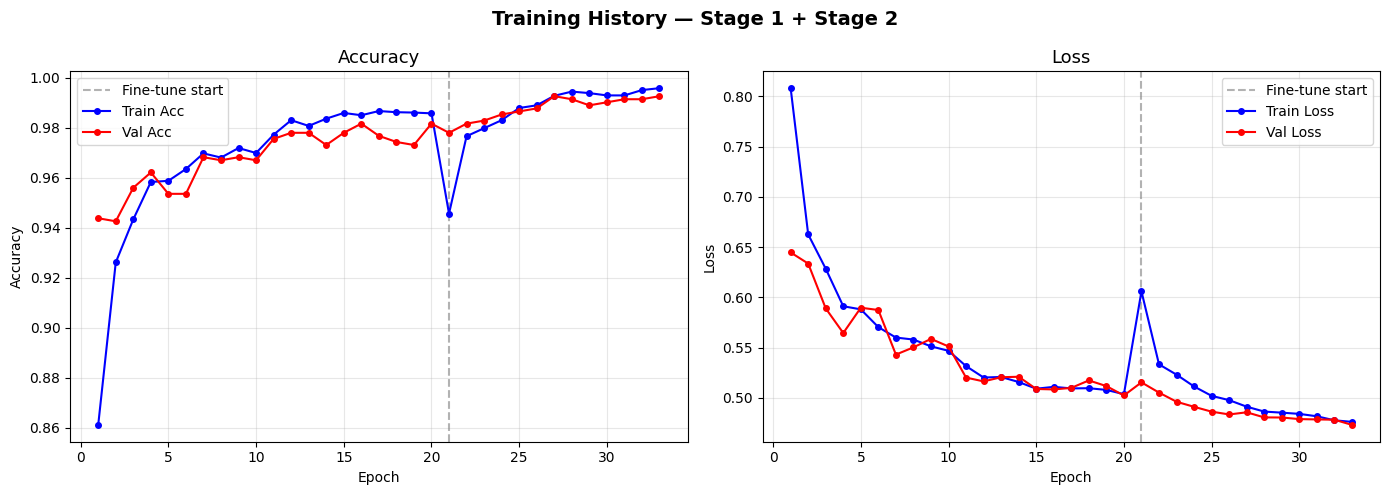

In [14]:
def plot_training_history(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    vacc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    vloss = h1.history['val_loss']     + h2.history['val_loss']
    epochs = range(1, len(acc) + 1)
    stage2_start = len(h1.history['accuracy']) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax in (ax1, ax2):
        ax.axvline(stage2_start, color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')

    ax1.plot(epochs, acc,  'b-o', label='Train Acc',  markersize=4)
    ax1.plot(epochs, vacc, 'r-o', label='Val Acc',    markersize=4)
    ax1.set_title('Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, loss,  'b-o', label='Train Loss', markersize=4)
    ax2.plot(epochs, vloss, 'r-o', label='Val Loss',   markersize=4)
    ax2.set_title('Loss', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle('Training History — Stage 1 + Stage 2', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'training_history.png', dpi=150)
    plt.show()

plot_training_history(history1, history2)

26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 607ms/step - accuracy: 0.9780 - loss: 0.5133

  Test Accuracy : 97.80%
  Test Loss     : 0.5133

  Macro Precision : 0.9741
  Macro Recall    : 0.9836
  Macro F1-Score  : 0.9787

Per-class Classification Report:
                     precision    recall  f1-score   support

   corn_common_rust      0.950     1.000     0.974        19
potato_early_blight      1.000     1.000     1.000       100
     potato_healthy      0.990     1.000     0.995       100
 potato_late_blight      0.990     1.000     0.995       100
tomato_early_blight      0.920     0.945     0.932       109
     tomato_healthy      0.979     0.945     0.962       201
 tomato_late_blight      0.990     0.995     0.992       191

           accuracy                          0.978       820
          macro avg      0.974     0.984     0.979       820
       weighted avg      0.978     0.978     0.978       820

✅ Saved → agrointelli_data\artifacts\reports\classification_report.txt


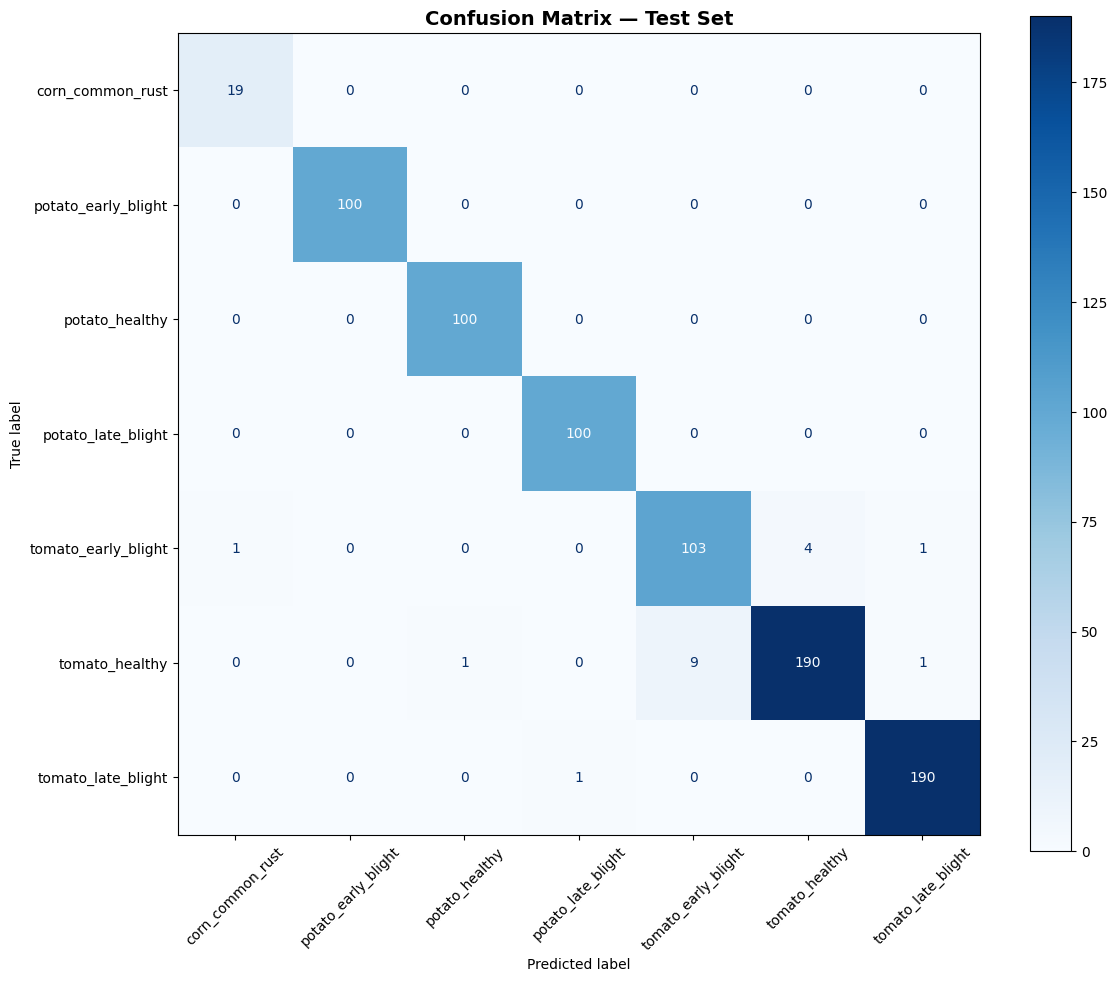

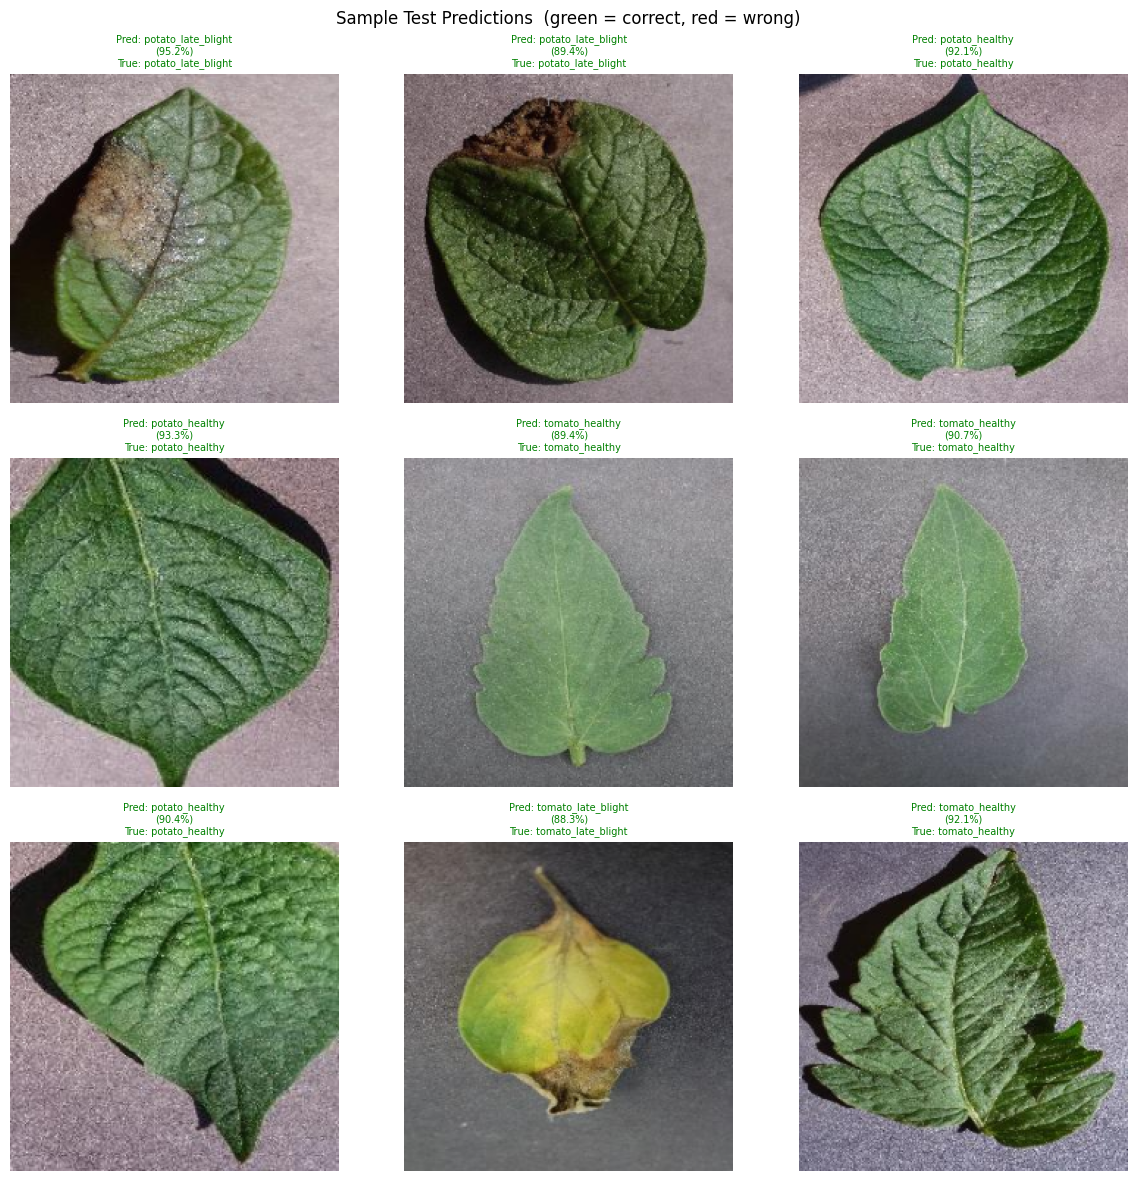

In [15]:
def collect_predictions(mdl, ds):
    """Batch-predict over the dual-input pipeline."""
    y_true_list, y_prob_list = [], []
    for (img_batch, weather_batch), label_batch in ds:
        probs = mdl.predict([img_batch, weather_batch], verbose=0)
        y_true_list.append(label_batch.numpy())
        y_prob_list.append(probs)
    y_true = np.concatenate(y_true_list)
    y_prob = np.concatenate(y_prob_list)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob


test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n{'='*55}")
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print(f"{'='*55}")

y_true, y_pred, y_prob = collect_predictions(model, test_ds)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
print(f'\n  Macro Precision : {prec:.4f}')
print(f'  Macro Recall    : {rec:.4f}')
print(f'  Macro F1-Score  : {f1:.4f}')

report_str = classification_report(
    y_true, y_pred, target_names=class_names, digits=3, zero_division=0
)
print('\nPer-class Classification Report:')
print(report_str)
(REPORT_DIR / 'classification_report.txt').write_text(report_str)
print(f'✅ Saved → {REPORT_DIR / "classification_report.txt"}')

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45
)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# ── Sample prediction grid ────────────────────────────────────────────────────
sample_idx = np.random.choice(len(y_true), min(9, len(y_true)), replace=False)
_test_paths = test_df['path'].values
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for ax_i, si in enumerate(sample_idx):
    img_d = cv2.imread(_test_paths[si])
    img_d = cv2.cvtColor(cv2.resize(img_d, (224, 224)), cv2.COLOR_BGR2RGB)
    axes[ax_i].imshow(img_d)
    colour = 'green' if y_pred[si] == y_true[si] else 'red'
    axes[ax_i].set_title(
        f"Pred: {class_names[y_pred[si]]}\n"
        f"({y_prob[si, y_pred[si]]*100:.1f}%)\n"
        f"True: {class_names[y_true[si]]}",
        fontsize=7, color=colour
    )
    axes[ax_i].axis('off')
plt.suptitle('Sample Test Predictions  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sample_predictions.png', dpi=150)
plt.show()

## 🌱 Section 12 — Image Preprocessing Pipeline

| Aspect | Lab Mode | Field Mode |
|---|---|---|
| Image source | Controlled conditions | Smartphone in field |
| Preprocessing | Minimal | Bilateral denoise + CLAHE + segmentation |
| Inference | Single-pass | Multi-patch ensemble |

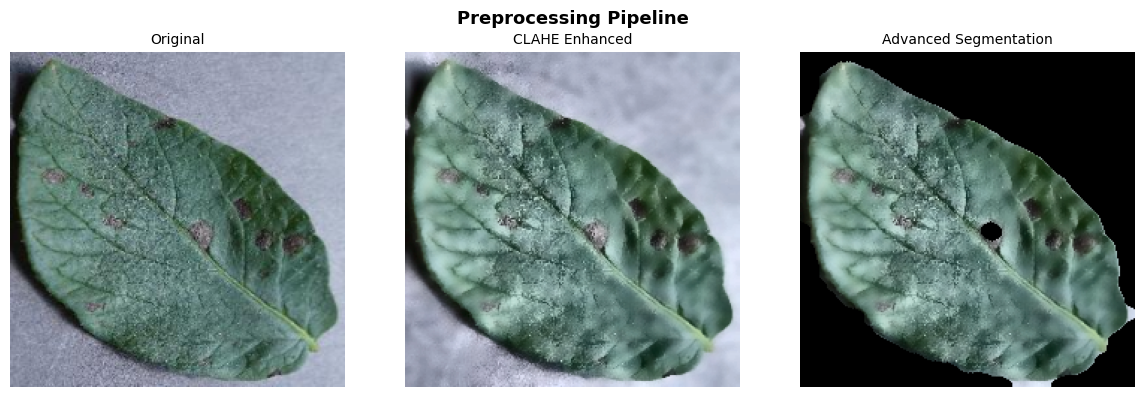

✅ Preprocessing utilities defined.


In [16]:
def segment_leaf_advanced(img_bgr):
    """HSV-based leaf segmentation covering green + diseased (brown/yellow) regions."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask_green  = cv2.inRange(hsv, np.array([22, 30, 30]), np.array([92, 255, 255]))
    mask_yellow = cv2.inRange(hsv, np.array([10, 30, 30]), np.array([25, 255, 255]))
    mask = cv2.bitwise_or(mask_green, mask_yellow)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)
    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    return segmented, mask


def enhance_field_image(img_bgr):
    """Bilateral denoise + CLAHE enhancement for field photos."""
    denoised = cv2.bilateralFilter(img_bgr, d=9, sigmaColor=75, sigmaSpace=75)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)


def calculate_blur_score(img_bgr):
    """Laplacian variance — higher = sharper image."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if len(img_bgr.shape) == 3 else img_bgr
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def apply_confidence_penalty(confidence, blur_score, blur_threshold=80.0):
    """Reduce confidence for blurry images by up to 20%."""
    if blur_score < blur_threshold:
        penalty = 0.20 * (1 - blur_score / blur_threshold)
        confidence = max(0.0, confidence - penalty)
    return confidence


def create_patches(img_bgr, patch_size=224, stride=112):
    """Split larger images into overlapping patches for ensemble inference."""
    h, w = img_bgr.shape[:2]
    patches = []
    for y in range(0, max(h - patch_size + 1, 1), stride):
        for x in range(0, max(w - patch_size + 1, 1), stride):
            patch = img_bgr[y:y + patch_size, x:x + patch_size]
            if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
                patch = cv2.resize(patch, (patch_size, patch_size))
            patches.append(patch)
    return patches if patches else [cv2.resize(img_bgr, (patch_size, patch_size))]


# ── Quick visualisation ───────────────────────────────────────────────────────
sample_path = pv_df.iloc[0]['path']
orig     = cv2.resize(cv2.imread(sample_path), (224, 224))
enhanced = enhance_field_image(orig)
seg_adv, mask = segment_leaf_advanced(enhanced)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes,
        [orig, enhanced, seg_adv],
        ['Original', 'CLAHE Enhanced', 'Advanced Segmentation']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('Preprocessing Pipeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'preprocessing_comparison.png', dpi=150)
plt.show()

print('✅ Preprocessing utilities defined.')

## 🔬 Section 13 — Prediction Pipelines

In [17]:
def normalise_weather_vector(weather):
    """Normalise raw weather values to [0, 1] for model input."""
    return np.array([
        np.clip(weather['temp_c']       / 50.0,  0, 1),
        np.clip(weather['humidity_pct'] / 100.0, 0, 1),
        np.clip(weather['rain_1h_mm']   / 10.0,  0, 1),
        np.clip(weather['wind_kmh']     / 50.0,  0, 1),
    ], dtype=np.float32)


def predict_lab_image(image_path, weather=None):
    """Fast single-pass prediction for clean lab-quality images."""
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot read image: {image_path}')
    img     = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)  # keep [0, 255]
    img_arr = np.expand_dims(img_rgb, axis=0)

    w_vec = normalise_weather_vector(weather) if weather else np.zeros(WEATHER_DIM, np.float32)
    w_arr = np.expand_dims(w_vec, axis=0)

    pred      = model.predict([img_arr, w_arr], verbose=0)[0]
    class_idx = int(np.argmax(pred))
    return {
        'prediction'  : class_names[class_idx],
        'confidence'  : float(pred[class_idx]),
        'all_probs'   : {class_names[i]: float(pred[i]) for i in range(NUM_CLASSES)},
        'mode'        : 'lab',
        'live_weather': weather is not None,
        'image_rgb'   : img_rgb / 255.0,
    }


def predict_field_image(image_path, weather=None):
    """Multi-step field prediction: enhance → segment → patch ensemble → blur penalty."""
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot read image: {image_path}')

    original        = cv2.resize(img_bgr, (448, 448))
    enhanced        = enhance_field_image(original)
    segmented, mask = segment_leaf_advanced(enhanced)
    blur_score      = calculate_blur_score(segmented)
    patches         = create_patches(segmented)

    w_vec = normalise_weather_vector(weather) if weather else np.zeros(WEATHER_DIM, np.float32)
    w_arr = np.expand_dims(w_vec, axis=0)

    patch_preds = []
    for patch in patches:
        patch_rgb = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB).astype(np.float32)
        patch_arr = np.expand_dims(patch_rgb, axis=0)
        patch_preds.append(model.predict([patch_arr, w_arr], verbose=0)[0])

    mean_pred  = np.mean(patch_preds, axis=0)
    class_idx  = int(np.argmax(mean_pred))
    confidence = float(mean_pred[class_idx])
    confidence = apply_confidence_penalty(confidence, blur_score)

    return {
        'prediction'  : class_names[class_idx],
        'confidence'  : confidence,
        'blur_score'  : round(blur_score, 2),
        'all_probs'   : {class_names[i]: float(mean_pred[i]) for i in range(NUM_CLASSES)},
        'mode'        : 'field',
        'live_weather': weather is not None,
        'original'    : original,
        'enhanced'    : enhanced,
        'segmented'   : segmented,
        'mask'        : mask,
    }


def smart_predict(image_path, mode='field', weather=None):
    """Unified prediction entry point."""
    if mode == 'lab':
        return predict_lab_image(image_path, weather=weather)
    return predict_field_image(image_path, weather=weather)


print('✅ Prediction pipelines defined.')
print('   Archive mode:  smart_predict("leaf.jpg", mode="field")')
print('   Live mode:     smart_predict("leaf.jpg", mode="field", weather=weather_dict)')

✅ Prediction pipelines defined.
   Archive mode:  smart_predict("leaf.jpg", mode="field")
   Live mode:     smart_predict("leaf.jpg", mode="field", weather=weather_dict)


## 🌤️ Section 14 — Live Weather Integration & Disease Risk Scoring

In [18]:
# ── OpenWeatherMap API key — replace with your own ────────────────────────────
OWM_API_KEY = '0af35111bc4b73ebb0b71d505e063680'


def fetch_weather():
    """Auto-detect location via IP → fetch live weather from OpenWeatherMap."""
    try:
        loc_data = requests.get('http://ip-api.com/json/', timeout=5).json()
        lat  = loc_data.get('lat', 22.57)
        lon  = loc_data.get('lon', 88.36)
        city = loc_data.get('city', 'Unknown')
        country = loc_data.get('country', 'IN')
    except Exception as e:
        print(f'  ⚠ Location lookup failed ({e}). Using Kolkata defaults.')
        lat, lon, city, country = 22.57, 88.36, 'Kolkata', 'India'

    try:
        url    = (f'http://api.openweathermap.org/data/2.5/weather'
                  f'?lat={lat}&lon={lon}&appid={OWM_API_KEY}&units=metric')
        w_data = requests.get(url, timeout=8).json()
        return {
            'city'        : city,
            'country'     : country,
            'lat'         : lat,
            'lon'         : lon,
            'temp_c'      : w_data['main']['temp'],
            'feels_like_c': w_data['main']['feels_like'],
            'humidity_pct': w_data['main']['humidity'],
            'condition'   : w_data['weather'][0]['description'],
            'wind_kmh'    : round(w_data['wind']['speed'] * 3.6, 1),
            'rain_1h_mm'  : w_data.get('rain', {}).get('1h', 0.0),
            'fetched_at'  : datetime.now().strftime('%Y-%m-%d %H:%M'),
        }
    except Exception as e:
        print(f'  ⚠ Weather API error: {e}')
        return {
            'city': city, 'country': country, 'lat': lat, 'lon': lon,
            'temp_c': 28.0, 'feels_like_c': 30.0, 'humidity_pct': 72,
            'condition': 'partly cloudy (fallback)', 'wind_kmh': 12.0,
            'rain_1h_mm': 0.0, 'fetched_at': datetime.now().strftime('%Y-%m-%d %H:%M'),
        }


weather = fetch_weather()
print(f"📍 Location  : {weather['city']}, {weather['country']}")
print(f"🌡  Temperature: {weather['temp_c']}°C (feels like {weather['feels_like_c']}°C)")
print(f"💧 Humidity   : {weather['humidity_pct']}%")
print(f"☁  Condition  : {weather['condition'].capitalize()}")
print(f"💨 Wind       : {weather['wind_kmh']} km/h")
print(f"🌧  Rain (1h)  : {weather['rain_1h_mm']} mm")
print(f"⏰ Fetched at : {weather['fetched_at']}")

📍 Location  : Kolkata, India
🌡  Temperature: 32.97°C (feels like 39.97°C)
💧 Humidity   : 66%
☁  Condition  : Haze
💨 Wind       : 13.0 km/h
🌧  Rain (1h)  : 0.0 mm
⏰ Fetched at : 2026-05-28 16:58


In [19]:
DISEASE_RISK_RULES = {
    'tomato_early_blight':   {'temp_range': (20, 30), 'humidity_min': 60,  'rain_sensitive': False,
                               'description': 'Alternaria solani — warm + humid conditions accelerate lesion spread.'},
    'tomato_late_blight':    {'temp_range': (10, 25), 'humidity_min': 80,  'rain_sensitive': True,
                               'description': 'Phytophthora infestans — cool, moist nights are highest-risk windows.'},
    'potato_early_blight':   {'temp_range': (20, 30), 'humidity_min': 60,  'rain_sensitive': False,
                               'description': 'Mirrors tomato early blight; warm days + humid nights ideal for Alternaria.'},
    'potato_late_blight':    {'temp_range': (10, 25), 'humidity_min': 80,  'rain_sensitive': True,
                               'description': 'Same pathogen as tomato late blight. Rain dramatically increases spread.'},
    'pepper_bacterial_spot': {'temp_range': (24, 32), 'humidity_min': 70,  'rain_sensitive': True,
                               'description': 'Xanthomonas — warm + rain creates splash dispersal of bacteria.'},
    'corn_common_rust':      {'temp_range': (16, 25), 'humidity_min': 70,  'rain_sensitive': False,
                               'description': 'Puccinia sorghi — moderate temps + humid nights accelerate urediniospore germination.'},
}

HEALTHY_CLASSES = {'tomato_healthy', 'potato_healthy', 'pepper_healthy', 'corn_healthy'}


def compute_spread_risk(disease_label, weather):
    """Compute disease spread risk score (0.0–1.0) from current weather conditions."""
    if disease_label in HEALTHY_CLASSES:
        return 0.0, 'None', 'Leaf appears healthy. No disease detected.'
    rules = DISEASE_RISK_RULES.get(disease_label)
    if rules is None:
        return 0.3, 'Low', 'No specific risk rules for this disease class.'

    t_min, t_max = rules['temp_range']
    h_min        = rules['humidity_min']
    temp         = weather['temp_c']
    humidity     = weather['humidity_pct']
    rain         = weather['rain_1h_mm']

    score, factors = 0.0, []

    if t_min <= temp <= t_max:
        t_score = 0.4 * (1 - abs(temp - (t_min + t_max) / 2) / ((t_max - t_min) / 2))
        score += t_score
        factors.append(f'temperature {temp}°C in optimal range ({t_min}–{t_max}°C)')
    else:
        factors.append(f'temperature {temp}°C outside optimal range')

    if humidity >= h_min:
        h_score = 0.35 * min((humidity - h_min) / (100 - h_min + 1e-6), 1.0)
        score += h_score
        factors.append(f'humidity {humidity}% ≥ threshold {h_min}%')
    else:
        factors.append(f'humidity {humidity}% below threshold {h_min}%')

    if rules['rain_sensitive'] and rain > 0:
        r_score = min(rain / 5.0, 1.0) * 0.25
        score += r_score
        factors.append(f'rainfall {rain} mm/h (splash risk)')

    score = min(score, 1.0)
    level = '🔴 HIGH' if score >= 0.70 else ('🟡 MODERATE' if score >= 0.40 else '🟢 LOW')
    explanation = rules['description'] + ' | Factors: ' + '; '.join(factors) + '.'
    return round(score, 3), level, explanation


print('✅ Weather risk scoring defined.')

✅ Weather risk scoring defined.


## 🔥 Section 15 — Grad-CAM Disease Localisation

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# -------------------------------------------------
# Utilities
# -------------------------------------------------
def find_nested_model(m, name):
    """Find a nested model by name."""
    if m.name == name:
        return m

    for layer in m.layers:
        if isinstance(layer, tf.keras.Model):
            if layer.name == name:
                return layer
            try:
                return find_nested_model(layer, name)
            except ValueError:
                pass

    raise ValueError(f"Nested model '{name}' not found.")

def get_last_conv_layer(m):
    """Auto-detect last Conv2D layer in a model (including nested models)."""
    for layer in reversed(m.layers):
        if isinstance(layer, layers.Conv2D):
            return layer
        if isinstance(layer, tf.keras.Model):
            try:
                return get_last_conv_layer(layer)
            except ValueError:
                pass

    try:
        return m.get_layer("top_activation")
    except Exception:
        raise ValueError("No Conv2D or 'top_activation' layer found.")

def get_first_input_tensor(m):
    """Return the first input tensor from a multi-input model."""
    if isinstance(m.inputs, (list, tuple)):
        return m.inputs[0]
    return m.input

# -------------------------------------------------
# Build Grad-CAM model
# -------------------------------------------------
# Get the backbone model that is inside the full model
backbone_in_model = find_nested_model(model, backbone.name)

# Get the last conv layer inside that backbone
_last_conv = get_last_conv_layer(backbone_in_model)

# Build a feature extractor from the backbone itself
# This is the key fix: use a model call, not raw .output from a disconnected graph
feature_extractor = tf.keras.Model(
    inputs=backbone_in_model.input,
    outputs=_last_conv.output,
    name="gradcam_feature_extractor"
)

# Connect that extractor to the full model's image input tensor
image_input_tensor = get_first_input_tensor(model)
conv_tensor = feature_extractor(image_input_tensor)

# Final Grad-CAM model
grad_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[conv_tensor, model.output],
    name="gradcam_model"
)

# -------------------------------------------------
# Grad-CAM heatmap
# -------------------------------------------------
def make_gradcam_heatmap(img_array, weather_array=None, pred_index=None):
    """Compute Grad-CAM heatmap for the predicted class."""
    if weather_array is None:
        weather_array = np.zeros((1, WEATHER_DIM), dtype=np.float32)

    img_t = tf.cast(img_array, tf.float32)
    w_t   = tf.cast(weather_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([img_t, w_t], training=False)

        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))

        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradient calculation failed.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# -------------------------------------------------
# Display Grad-CAM
# -------------------------------------------------
def display_gradcam(image_path, mode="field", weather=None, save=True):
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    img = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_arr = np.expand_dims(img_rgb.astype(np.float32), axis=0)

    if weather is not None:
        w_vec = normalise_weather_vector(weather)
    else:
        w_vec = np.zeros(WEATHER_DIM, dtype=np.float32)

    w_arr = np.expand_dims(w_vec.astype(np.float32), axis=0)

    # Your prediction function
    result = smart_predict(image_path, mode=mode, weather=weather)

    heatmap = make_gradcam_heatmap(img_arr, weather_array=w_arr)

    heat_r = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heat_c = cv2.applyColorMap((heat_r * 255).astype(np.uint8), cv2.COLORMAP_JET)

    overlay = cv2.cvtColor(
        cv2.addWeighted(img, 0.55, heat_c, 0.45, 0),
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM Disease Localisation", fontsize=11)
    axes[1].axis("off")

    fig.suptitle(
        f"Prediction: {result['prediction']}  |  Confidence: {result['confidence']*100:.1f}%",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()

    if save:
        GRADCAM_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            GRADCAM_DIR / f"gradcam_{Path(image_path).stem}.png",
            dpi=150,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

    return result

print("✅ Grad-CAM ready.")
print('Usage: display_gradcam("leaf.jpg", mode="field")')

✅ Grad-CAM ready.
Usage: display_gradcam("leaf.jpg", mode="field")


## 🩺 Section 16 — Agronomic Advice & Quality Checks

In [28]:
def image_quality_check(image_path):
    """Assess brightness, contrast, and sharpness of the input image."""
    img = cv2.imread(str(image_path))
    if img is None:
        return {'ok': False, 'reason': 'unreadable', 'warnings': ['unreadable'],
                'brightness': 0, 'contrast': 0, 'sharpness': 0}
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(gray.mean())
    contrast   = float(gray.std())
    sharpness  = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    warns = []
    if brightness < 50:    warns.append('too dark')
    elif brightness > 205: warns.append('too bright')
    if contrast < 20:      warns.append('low contrast')
    if sharpness < 60:     warns.append('blurry')
    return {
        'ok'        : len(warns) == 0,
        'brightness': round(brightness, 2),
        'contrast'  : round(contrast, 2),
        'sharpness' : round(sharpness, 2),
        'warnings'  : warns,
    }


def severity_proxy(image_path):
    """Estimate disease severity as lesion ratio (0.0–1.0) via HSV analysis."""
    img = cv2.imread(str(image_path))
    if img is None:
        return {'severity': 'unknown', 'lesion_ratio': 0.0}
    img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    leaf = (hsv[:, :, 1] > 40) & (hsv[:, :, 2] > 40)
    if leaf.sum() < 100:
        return {'severity': 'unknown', 'lesion_ratio': 0.0}
    bgr    = img.astype(np.int16)
    lesion = leaf & ((bgr[:, :, 1] < 120) | (bgr[:, :, 2] > 140))
    ratio  = float(lesion.sum() / leaf.sum())
    sev    = ('healthy / very mild' if ratio < 0.08
              else ('early / moderate' if ratio < 0.22 else 'severe'))
    return {'severity': sev, 'lesion_ratio': round(ratio, 4)}


ADVICE_RULES = [
    ('early_blight', 'Apply protectant fungicide. Remove lower infected leaves. Maintain dry canopy.'),
    ('late_blight',  'Act immediately — late blight spreads very fast. Apply systemic fungicide within 24h.'),
    ('blight',       'Remove infected leaves and avoid overhead watering. Apply copper-based fungicide.'),
    ('bacterial',    'Avoid overhead irrigation. Remove affected tissue. Apply copper bactericide.'),
    ('rust',         'Improve field airflow. Monitor spread daily. Apply fungicide at first new lesions.'),
    ('healthy',      'No disease detected. Continue monitoring every 3–5 days.'),
]


def get_care_advice(class_name):
    low = class_name.lower()
    for key, advice in ADVICE_RULES:
        if key in low:
            return advice
    return 'No specific advice. Monitor regularly and consult your local agronomist.'


def predict_single(image_path, field_mode=True, weather=None):
    """
    Unified entry point returning everything the web API needs.
    Returns: prediction, confidence, top3, quality, severity, advice, spread_risk.
    """
    image_path = str(image_path)
    quality    = image_quality_check(image_path)
    severity   = severity_proxy(image_path)
    mode_str   = 'field' if field_mode else 'lab'
    result     = smart_predict(image_path, mode=mode_str, weather=weather)

    best_class = result['prediction']
    best_conf  = result['confidence']
    top3 = sorted(result['all_probs'].items(), key=lambda x: x[1], reverse=True)[:3]

    if field_mode:
        conf_tier = ('high confidence' if best_conf >= 0.85
                     else ('medium confidence' if best_conf >= 0.55
                           else 'low confidence — retake image'))
    else:
        conf_tier = 'lab mode'

    spread_risk = None
    if weather:
        risk_score, risk_level, risk_expl = compute_spread_risk(best_class, weather)
        spread_risk = {'score': risk_score, 'level': risk_level, 'explanation': risk_expl}

    return {
        'prediction'     : best_class,
        'confidence'     : round(best_conf, 4),
        'confidence_pct' : round(best_conf * 100, 2),
        'confidence_tier': conf_tier,
        'top3'           : top3,
        'quality'        : quality,
        'severity'       : severity,
        'advice'         : get_care_advice(best_class),
        'spread_risk'    : spread_risk,
        'mode'           : mode_str,
        'live_weather'   : weather is not None,
    }


print('✅ predict_single() ready — this is the function called by the Flask backend.')
print('   Usage: result = predict_single("leaf.jpg", field_mode=True)')
print('   Live:  result = predict_single("leaf.jpg", field_mode=True, weather=weather)')

✅ predict_single() ready — this is the function called by the Flask backend.
   Usage: result = predict_single("leaf.jpg", field_mode=True)
   Live:  result = predict_single("leaf.jpg", field_mode=True, weather=weather)


## 📈 Section 17 — Disease Progression Tracking

In [29]:
def estimate_severity(mask):
    """Estimate disease severity as fraction of non-leaf pixels in bounding region."""
    if mask is None or mask.size == 0:
        return 0.0
    total    = mask.shape[0] * mask.shape[1]
    nonzero  = np.count_nonzero(mask)
    non_leaf = total - nonzero
    return round(min((non_leaf / total) * 100, 100.0), 2)


def analyze_progression(image_paths, dates=None, mode='field', weather_data=None):
    """
    Analyse a sequence of leaf images to track disease progression over time.
    Returns a DataFrame with one row per observation.
    """
    if weather_data is None:
        weather_data = fetch_weather()

    records = []
    for idx, image_path in enumerate(image_paths):
        date_label = dates[idx] if dates else f'Day {idx+1}'
        result     = smart_predict(image_path, mode=mode)
        mask       = result.get('mask', None)
        severity   = estimate_severity(mask) if mask is not None else 0.0
        risk_score, risk_level, _ = compute_spread_risk(result['prediction'], weather_data)
        records.append({
            'date'           : date_label,
            'prediction'     : result['prediction'],
            'confidence_pct' : round(result['confidence'] * 100, 2),
            'severity_pct'   : severity,
            'blur_score'     : result.get('blur_score', None),
            'spread_risk'    : risk_level,
            'spread_score'   : risk_score,
            'temp_c'         : weather_data['temp_c'],
            'humidity_pct'   : weather_data['humidity_pct'],
        })
        print(f'  [{date_label}] {result["prediction"]} | severity {severity}% | {risk_level}')

    return pd.DataFrame(records)


def plot_progression(progression_df):
    """Plot disease severity and spread risk score over time."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    dates = progression_df['date']

    ax1.plot(dates, progression_df['severity_pct'],
             marker='o', linewidth=2, color='tomato', markersize=8)
    ax1.fill_between(dates, progression_df['severity_pct'], alpha=0.15, color='tomato')
    ax1.set_title('Disease Severity Over Time', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Date'); ax1.set_ylabel('Estimated Severity (%)')
    ax1.set_ylim(0, 100); ax1.grid(alpha=0.3)

    ax2.plot(dates, progression_df['spread_score'],
             marker='s', linewidth=2, color='steelblue', markersize=8)
    ax2.fill_between(dates, progression_df['spread_score'], alpha=0.15, color='steelblue')
    ax2.axhline(0.70, color='red',    linestyle='--', alpha=0.6, label='High risk')
    ax2.axhline(0.40, color='orange', linestyle='--', alpha=0.6, label='Moderate risk')
    ax2.set_title('Spread Risk Score Over Time', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Date'); ax2.set_ylabel('Risk Score (0–1)')
    ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

    disease = progression_df['prediction'].iloc[0].replace('_', ' ').title()
    plt.suptitle(f'Progression Tracker — {disease}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'progression_tracking.png', dpi=150)
    plt.show()


print('✅ Progression tracking utilities ready.')
print('   Usage:')
print('   progression_df = analyze_progression(["day1.jpg", "day5.jpg"], dates=["Day 1", "Day 5"])')
print('   plot_progression(progression_df)')

✅ Progression tracking utilities ready.
   Usage:
   progression_df = analyze_progression(["day1.jpg", "day5.jpg"], dates=["Day 1", "Day 5"])
   plot_progression(progression_df)


## 💾 Section 18 — Save Final Model & Summary Report

In [30]:
# ── Save full Keras model ─────────────────────────────────────────────────────
final_model_path = MODEL_DIR / 'agrointelli_phase1_final.keras'
model.save(str(final_model_path))
print(f'✅ Model saved → {final_model_path}')

# ── Save class index map ──────────────────────────────────────────────────────
class_map_path = MODEL_DIR / 'class_index_map.json'
with open(class_map_path, 'w') as f:
    json.dump(class_to_idx, f, indent=2)
print(f'✅ Class map saved → {class_map_path}')

# ── Save advice map for the web UI ───────────────────────────────────────────
advice_map = {
    cls: {'summary': get_care_advice(cls),
          'prevention': 'Keep canopy dry, monitor regularly, remove infected tissue promptly.'}
    for cls in class_names
}
advice_path = MODEL_DIR / 'advice.json'
with open(advice_path, 'w') as f:
    json.dump(advice_map, f, indent=2)
print(f'✅ Advice map saved → {advice_path}')

# ── Summary report ────────────────────────────────────────────────────────────
summary = {
    'project'          : 'AgroIntelli Phase 1',
    'backbone'         : 'EfficientNetB0',
    'image_size'       : IMG_SIZE,
    'batch_size'       : BATCH_SIZE,
    'num_classes'      : NUM_CLASSES,
    'class_names'      : class_names,
    'train_samples'    : len(train_df),
    'val_samples'      : len(val_df),
    'test_samples'     : len(test_df),
    'stage1_epochs'    : len(history1.history['accuracy']),
    'stage2_epochs'    : len(history2.history['accuracy']),
    'best_val_accuracy': round(max(history1.history['val_accuracy'] +
                                   history2.history['val_accuracy']), 4),
    'test_accuracy'    : round(test_acc, 4),
    'weather_api'      : 'OpenWeatherMap',
    'datasets'         : ['PlantVillage (Mendeley)', 'PlantDoc (GitHub)'],
    'saved_at'         : datetime.now().isoformat(),
}

summary_path = REPORT_DIR / 'phase1_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'✅ Summary report saved → {summary_path}')

print('\n' + '=' * 55)
print('  AgroIntelli Phase 1 — TRAINING COMPLETE')
print('=' * 55)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Model path    : {final_model_path}')
print(f'  Class map     : {class_map_path}')
print()
print('  ✅ Copy model artifacts to backend/models/ to start the web server.')

✅ Model saved → agrointelli_data\artifacts\models\agrointelli_phase1_final.keras
✅ Class map saved → agrointelli_data\artifacts\models\class_index_map.json
✅ Advice map saved → agrointelli_data\artifacts\models\advice.json
✅ Summary report saved → agrointelli_data\artifacts\reports\phase1_summary.json

  AgroIntelli Phase 1 — TRAINING COMPLETE
  Test Accuracy : 97.80%
  Model path    : agrointelli_data\artifacts\models\agrointelli_phase1_final.keras
  Class map     : agrointelli_data\artifacts\models\class_index_map.json

  ✅ Copy model artifacts to backend/models/ to start the web server.
